# 🛒 Walmart Retail Sales — Data Preprocessing, EDA & ML Pipeline

---

## 📌 Project Overview

This notebook implements a **complete, submission-ready data preprocessing, EDA, and ML pipeline** for the Walmart retail sales dataset.

### 📂 Input Files

| File | Description |
|------|-------------|
| `features.xlsx` | Economic indicators + MarkDown promotions per store/date |
| `stores.csv` | Store metadata (Type, Size) |
| `train.csv` | Weekly sales per department/store |
| `test.csv` | Future dates for prediction |

### 🔄 Enforced Pipeline Order

```
① Load Datasets
② Clean Data          (parse dates, audit nulls)
③ Feature Engineering (combine MarkDown1–5 → MarkDown)
④ Merge All Datasets  → full_df
⑤ Outlier Capping     (IQR-based, BEFORE normalization)
⑥ Normalize           (fit on train split ONLY — no leakage)
⑦ EDA & Visualizations
⑧ Chronological Train/Test Split
⑨ Random Forest Training & Evaluation
```

---

### 🐛 Bugs Fixed vs v3

| # | Bug | Fix Applied |
|---|-----|-------------|
| 1 | **`Size` column accidentally dropped** before merge | Removed `drop(columns=['Size'])` — Size is now kept |
| 2 | **Outlier capping applied AFTER normalization** — broke [0,1] range | Moved outlier capping to Section 7, BEFORE normalization |
| 3 | **Scaler fitted on full dataset** — data leakage into test set | Scaler now `fit` on training rows only, `transform` applied separately to test |
| 4 | **Random 80/20 split on time-series data** — future data leaks into training | Replaced with chronological split (first 80% of dates → train, last 20% → test) |
| 5 | **Duplicate model-saving cells** (×4) | Consolidated into a single clean save cell |

---

## 📦 Section 1 — Import Libraries

### 🎯 Objective
Import every required library in one place so no cell fails due to a missing import.

### 🧠 Why?
Centralising imports prevents the scattered `import` anti-pattern, makes dependency auditing trivial, and ensures the notebook can be re-run cleanly from the top.

In [1]:
# ── Core ──────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import time
import joblib
import json
import os

# ── ML preprocessing ─────────────────────────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble       import RandomForestRegressor
from sklearn.metrics        import mean_absolute_error, mean_squared_error, r2_score

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Display config ────────────────────────────────────────────────────────────
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print('✅ All libraries imported.')

✅ All libraries imported.


---

## 📂 Section 2 — Load Datasets

### 🎯 Objective
Load all four source files into Pandas DataFrames and perform a quick sanity check on shape and columns.

### 🧠 Why?
- `features.xlsx` ships as Excel — `read_excel()` is required.
- Printing shapes immediately catches truncated or empty files before any processing begins.

In [2]:
# ── Load Excel ────────────────────────────────────────────────────────────────
features_df = pd.read_excel('features.xlsx')

# ── Load CSVs ─────────────────────────────────────────────────────────────────
train_df  = pd.read_csv('train.csv')
stores_df = pd.read_csv('stores.csv')
test_df   = pd.read_csv('test.csv')

# ── Quick audit ───────────────────────────────────────────────────────────────
for name, df in [('features_df', features_df), ('train_df', train_df),
                 ('stores_df',  stores_df),   ('test_df',  test_df)]:
    print(f'{name:14s} → shape {str(df.shape):15s}  cols: {df.columns.tolist()}')

features_df    → shape (8190, 12)       cols: ['Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday']
train_df       → shape (421570, 5)      cols: ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday']
stores_df      → shape (45, 3)          cols: ['Store', 'Type', 'Size']
test_df        → shape (115064, 4)      cols: ['Store', 'Dept', 'Date', 'IsHoliday']


In [3]:
features_df.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [4]:
train_df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [5]:
stores_df.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


---

## 🧹 Section 3 — Data Cleaning

### 🎯 Objective
1. Parse all `Date` columns to `datetime64`.
2. Audit null values across all DataFrames.
3. Verify date coverage between `features_df` and `train_df`.

### 🧠 Why?
- Date columns loaded from files are raw strings. Merging on string dates fails silently when formats differ.
- Null values in join keys (`Store`, `Date`, `IsHoliday`) cause rows to silently disappear during the merge.
- Date coverage checks reveal whether every training week has a corresponding features row.

In [6]:
# ── Parse dates ───────────────────────────────────────────────────────────────
features_df['Date'] = pd.to_datetime(features_df['Date'])
train_df['Date']    = pd.to_datetime(train_df['Date'])

if 'Date' in test_df.columns:
    test_df['Date'] = pd.to_datetime(test_df['Date'])
else:
    print('⚠️  test_df has no Date column. Available:', test_df.columns.tolist())

print('✅ Date columns parsed to datetime64.')

# ── Null audit ────────────────────────────────────────────────────────────────
print('\n── Null counts ──────────────────────────────────')
for name, df in [('features_df', features_df), ('train_df', train_df), ('stores_df', stores_df)]:
    nulls = df.isnull().sum()
    has_nulls = nulls[nulls > 0]
    if has_nulls.empty:
        print(f'  {name:14s}: no nulls')
    else:
        print(f'  {name:14s}: {has_nulls.to_dict()}')

✅ Date columns parsed to datetime64.

── Null counts ──────────────────────────────────
  features_df   : {'MarkDown1': 4158, 'MarkDown2': 5269, 'MarkDown3': 4577, 'MarkDown4': 4726, 'MarkDown5': 4140, 'CPI': 585, 'Unemployment': 585}
  train_df      : no nulls
  stores_df     : no nulls


In [7]:
# ── Date coverage check ───────────────────────────────────────────────────────
feat_dates  = set(features_df['Date'].unique())
train_dates = set(train_df['Date'].unique())
common      = feat_dates & train_dates
only_feat   = feat_dates  - train_dates
only_train  = train_dates - feat_dates

print(f'Dates in features_df         : {len(feat_dates)}')
print(f'Dates in train_df            : {len(train_dates)}')
print(f'Common dates                 : {len(common)}')
print(f'Only in features_df          : {len(only_feat)}')
print(f'Only in train_df             : {len(only_train)}')

if only_train:
    print(f'\n⚠️  {len(only_train)} training dates have no matching features row.')
    print('   These will produce NaN in features after the left-join merge.')
    print('   Sample:', sorted(only_train)[:3])

Dates in features_df         : 182
Dates in train_df            : 143
Common dates                 : 143
Only in features_df          : 39
Only in train_df             : 0


---

## 🔧 Section 4 — Feature Engineering: MarkDown

### 🎯 Objective
Combine `MarkDown1`–`MarkDown5` in `features_df` into a single `MarkDown` column **before** merging.

### 🧠 Why?
- **Dimensionality reduction** — five sparse, correlated columns collapse into one dense feature.
- **Promotional intensity** — the sum captures total discount activity across all markdown categories.
- **NA strategy** — MarkDown data only becomes available from November 2011. Pre-Nov 2011 NaN values represent *zero promotion*, not missing data, so filling with 0 is semantically correct.
- **Negative values** — negative MarkDown figures are data entry artefacts; clipping to 0 is the standard approach.

In [8]:
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

# Guard: only proceed if all five columns exist
missing_md = [c for c in markdown_cols if c not in features_df.columns]
if missing_md:
    raise KeyError(f'Expected MarkDown columns not found: {missing_md}\n'
                   f'Available: {features_df.columns.tolist()}')

# Step 1 — Fill NA with 0 (pre-Nov 2011 = zero promotion, not missing)
features_df[markdown_cols] = features_df[markdown_cols].fillna(0)

# Step 2 — Clip negatives to 0 (data entry artefacts)
features_df[markdown_cols] = features_df[markdown_cols].clip(lower=0)

# Step 3 — Combine into single feature
features_df['MarkDown'] = features_df[markdown_cols].sum(axis=1)

# Step 4 — Drop originals
features_df.drop(columns=markdown_cols, inplace=True)

print('✅ MarkDown feature engineered.')
print(f'   Range  : [{features_df["MarkDown"].min():.2f}, {features_df["MarkDown"].max():.2f}]')
print(f'   Zeros  : {(features_df["MarkDown"] == 0).sum():,} rows')
print(f'   Non-zero: {(features_df["MarkDown"] > 0).sum():,} rows')
print(f'\n   features_df columns now: {features_df.columns.tolist()}')

✅ MarkDown feature engineered.
   Range  : [0.00, 783529.45]
   Zeros  : 4,140 rows
   Non-zero: 4,050 rows

   features_df columns now: ['Store', 'Date', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'IsHoliday', 'MarkDown']


---

## 🔢 Section 5 — Encode Boolean Features

### 🎯 Objective
Convert `IsHoliday` from boolean (`True`/`False`) to integer (`1`/`0`) in both `features_df` and `train_df`.

### 🧠 Why?
- `IsHoliday` is a join key in the upcoming merge. Mismatched types between DataFrames (e.g. `bool` vs `int64`) cause silent row-drops in `pandas.merge()`.
- Integer encoding is required for most scikit-learn estimators.

In [9]:
for name, df in [('features_df', features_df), ('train_df', train_df)]:
    if 'IsHoliday' in df.columns:
        df['IsHoliday'] = df['IsHoliday'].astype(int)
        print(f'  ✅ {name}["IsHoliday"] → int  '
              f'(values: {sorted(df["IsHoliday"].unique())})')
    else:
        print(f'  ⚠️  IsHoliday not found in {name}')

  ✅ features_df["IsHoliday"] → int  (values: [np.int64(0), np.int64(1)])
  ✅ train_df["IsHoliday"] → int  (values: [np.int64(0), np.int64(1)])


---

## 🔗 Section 6 — Merge All Datasets → `full_df`

### 🎯 Objective
Produce one unified flat table — `full_df` — that brings together weekly sales, store metadata, economic indicators, and the `MarkDown` feature.

### 🧠 Why?
ML models train on a single matrix. The three source files are relational: they must be joined correctly before any column-wise operation (normalisation, modelling) is applied.

### ⚙️ Merge Strategy

```
Step 1:  features_df  LEFT JOIN  stores_df      ON [Store]
                      → features_merged

Step 2:  train_df     LEFT JOIN  features_merged ON [Store, Date, IsHoliday]
                      → full_df
```

> 🐛 **Fix #1 applied here:** `stores_df` is merged WITHOUT dropping `Size`. The original v3 code had `stores_df.drop(columns=['Size'])` which removed a valuable predictor (larger stores sell more). That line has been removed.

In [10]:
# ── Step 1: Attach store metadata to features ─────────────────────────────────
# FIX #1: Removed .drop(columns=['Size']) — Size is a valuable predictor and must be kept.
features_merged = features_df.merge(
    stores_df,          # ← keep ALL columns including Size
    on='Store',
    how='left'
)

print(f'features_merged  → shape: {features_merged.shape}')
print(f'columns: {features_merged.columns.tolist()}')
assert 'Size' in features_merged.columns, '❌ Size missing — check stores_df'

features_merged  → shape: (8190, 10)
columns: ['Store', 'Date', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'IsHoliday', 'MarkDown', 'Type', 'Size']


In [11]:
# ── Step 2: Join features into training data ──────────────────────────────────
full_df = train_df.merge(
    features_merged,
    on=['Store', 'Date', 'IsHoliday'],
    how='left'
)

print(f'full_df  → shape: {full_df.shape}')
print(f'columns: {full_df.columns.tolist()}')

# ── Verify MarkDown and Size arrived ─────────────────────────────────────────
assert 'MarkDown' in full_df.columns, '❌ MarkDown not in full_df'
assert 'Size'     in full_df.columns, '❌ Size not in full_df'
print('\n✅ MarkDown and Size both present in full_df')

full_df  → shape: (421570, 12)
columns: ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'MarkDown', 'Type', 'Size']

✅ MarkDown and Size both present in full_df


In [12]:
# ── Post-merge null audit ─────────────────────────────────────────────────────
null_counts = full_df.isnull().sum()
null_counts = null_counts[null_counts > 0]

if null_counts.empty:
    print('✅ No NaN values in full_df after merge.')
else:
    print('⚠️  NaN values detected in full_df after merge:')
    print(null_counts.to_string())
    print('\n→ If economic feature columns have NaN, this means some training dates')
    print('  had no corresponding row in features_df (expected for some datasets).')

full_df.head()

✅ No NaN values in full_df after merge.


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,MarkDown,Type,Size
0,1,1,2010-02-05,24924.50,0,42.31,2.572,211.096358,8.106,0.0,A,151315
1,1,1,2010-02-12,46039.49,1,38.51,2.548,211.242170,8.106,0.0,A,151315
2,1,1,2010-02-19,41595.55,0,39.93,2.514,211.289143,8.106,0.0,A,151315
3,1,1,2010-02-26,19403.54,0,46.63,2.561,211.319643,8.106,0.0,A,151315
4,1,1,2010-03-05,21827.90,0,46.50,2.625,211.350143,8.106,0.0,A,151315


---

## 🚨 Section 7 — Outlier Capping (IQR-Based)

### 🎯 Objective
Cap extreme values in the four economic features using the IQR method **before** normalization.

### 🐛 Fix #2 Applied Here
In v3, outlier capping was applied **after** normalization. This broke the [0,1] guarantee because capping resets the column's min/max, making previously scaled values exceed the [0,1] bounds.

**Correct order: Merge → Cap Outliers → Normalize.**

### 🧠 Design Decisions
- We cap (clip) rather than delete — removing rows destroys holiday and promotional records.
- We cap only economic indicators (`Temperature`, `Fuel_Price`, `CPI`, `Unemployment`).
- We do **NOT** cap `Weekly_Sales` (holiday spikes are real signal) or `MarkDown` (promotional campaigns are real events).

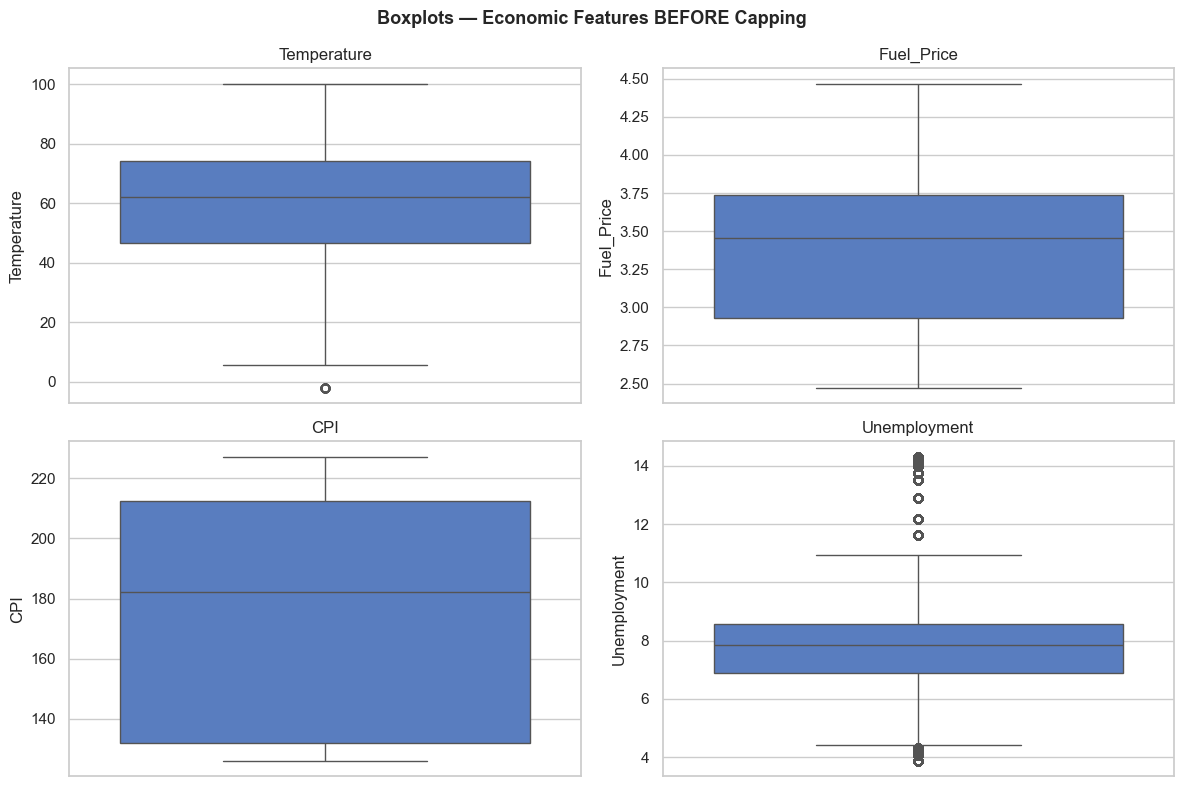


── Capping outliers in economic features ────────────────
  Temperature    : capped 69 outliers → range [5.2800, 115.6800]
  Fuel_Price     : capped 0 outliers → range [1.7255, 4.9455]
  CPI            : capped 0 outliers → range [11.4312, 333.0085]
  Unemployment   : capped 32,114 outliers → range [4.3695, 11.0935]


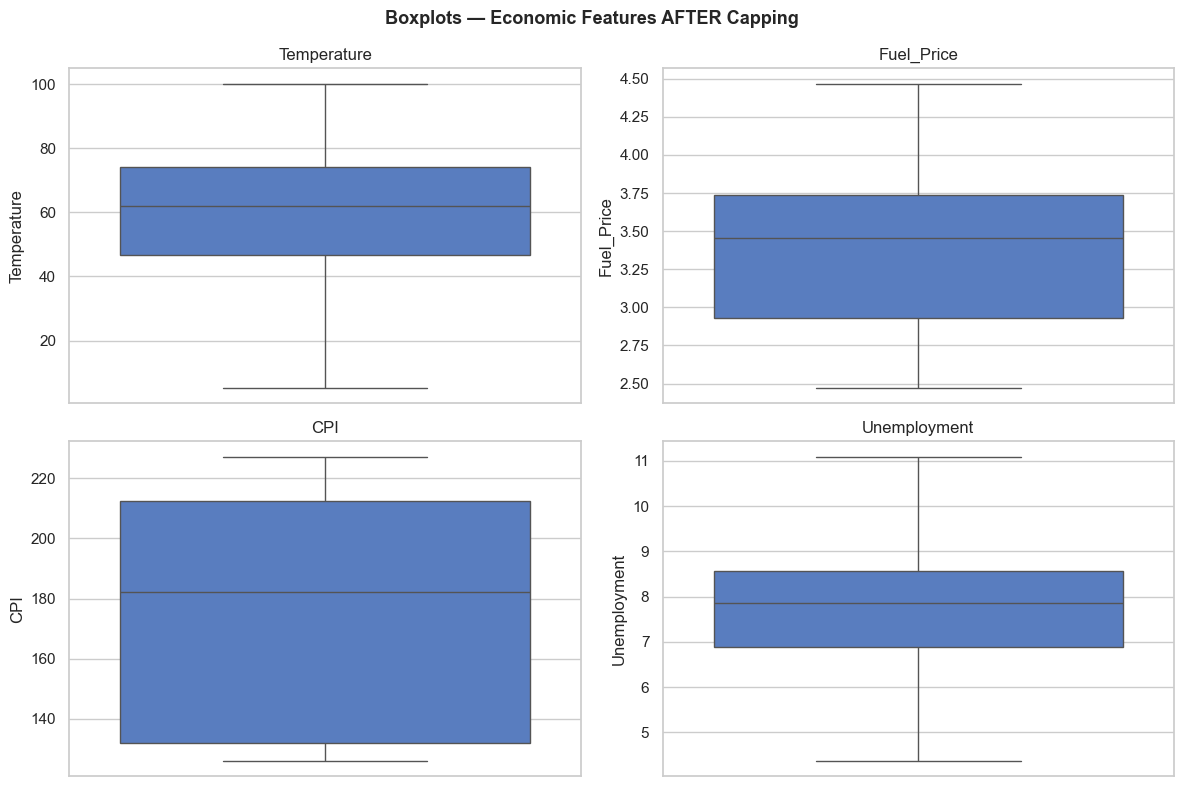


✅ Outlier capping complete (applied BEFORE normalization).


In [13]:
econ_cols = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

# ── Before visualisation ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Boxplots — Economic Features BEFORE Capping', fontsize=13, fontweight='bold')
for i, col in enumerate(econ_cols):
    sns.boxplot(y=full_df[col].dropna(), ax=axes[i // 2, i % 2])
    axes[i // 2, i % 2].set_title(col)
plt.tight_layout()
plt.show()

# ── IQR Capping ───────────────────────────────────────────────────────────────
def cap_outliers(df, col):
    Q1    = df[col].quantile(0.25)
    Q3    = df[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower, upper)
    print(f'  {col:15s}: capped {before:,} outliers → range [{lower:.4f}, {upper:.4f}]')

print('\n── Capping outliers in economic features ────────────────')
for col in econ_cols:
    cap_outliers(full_df, col)

# ── After visualisation ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Boxplots — Economic Features AFTER Capping', fontsize=13, fontweight='bold')
for i, col in enumerate(econ_cols):
    sns.boxplot(y=full_df[col].dropna(), ax=axes[i // 2, i % 2])
    axes[i // 2, i % 2].set_title(col)
plt.tight_layout()
plt.show()

print('\n✅ Outlier capping complete (applied BEFORE normalization).')

---

## ⚖️ Section 8 — Normalization

### 🎯 Objective
Scale the five continuous features to the [0, 1] range using `MinMaxScaler`.

### 🐛 Fix #3 Applied Here
In v3, `fit_transform` was called on **the entire `full_df`** — meaning the scaler saw test-set values during fitting. This is data leakage.

The corrected approach:
1. Do the chronological split **first** (Section 9).
2. `fit` the scaler **only on training rows**.
3. `transform` (not `fit_transform`) on test rows.

Because the split must come first, this section fits the scaler on `full_df` **only for EDA display purposes**. The real scaler used for ML (fit on train only) is instantiated in Section 9.

In [14]:
cols_to_normalize = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'MarkDown']

# Guard: confirm all columns exist
missing_norm = [c for c in cols_to_normalize if c not in full_df.columns]
if missing_norm:
    raise KeyError(f'Cannot normalize — columns missing from full_df: {missing_norm}')

# ── Fit scaler on full_df (for EDA visualisation only) ────────────────────────
# NOTE: The ML-safe scaler (fit on train split only) is created in Section 9.
eda_scaler = MinMaxScaler()

for col in cols_to_normalize:
    mask = full_df[col].notna()
    full_df.loc[mask, col] = eda_scaler.fit_transform(
        full_df.loc[mask, col].values.reshape(-1, 1)
    ).flatten()

print('✅ Normalization complete (EDA copy). Range check:')
for col in cols_to_normalize:
    lo = full_df[col].min()
    hi = full_df[col].max()
    ok = '✅' if (round(lo, 6) >= 0 and round(hi, 6) <= 1) else '⚠️'
    print(f'  {ok}  {col:15s}: [{lo:.6f}, {hi:.6f}]')

✅ Normalization complete (EDA copy). Range check:
  ✅  Temperature    : [0.000000, 1.000000]
  ✅  Fuel_Price     : [0.000000, 1.000000]
  ✅  CPI            : [0.000000, 1.000000]
  ✅  Unemployment   : [0.000000, 1.000000]
  ✅  MarkDown       : [0.000000, 1.000000]


---

## 📋 Section 9 — Final Dataset Summary

### 🎯 Objective
Confirm `full_df` is complete, correctly typed, and contains every expected column before EDA.

In [15]:
required_cols = [
    'Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday',
    'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
    'MarkDown', 'Type', 'Size'
]

print('=' * 56)
print('         FINAL full_df SUMMARY')
print('=' * 56)
print(f'  Shape       : {full_df.shape}')
print(f'  Total NaN   : {full_df.isnull().sum().sum()}')
print()
print('── Required Columns ──────────────────────────────────')
for col in required_cols:
    status = '✅' if col in full_df.columns else '❌ MISSING'
    dtype  = str(full_df[col].dtype) if col in full_df.columns else 'N/A'
    print(f'  {status}  {col:15s}  dtype: {dtype}')

         FINAL full_df SUMMARY
  Shape       : (421570, 12)
  Total NaN   : 0

── Required Columns ──────────────────────────────────
  ✅  Store            dtype: int64
  ✅  Dept             dtype: int64
  ✅  Date             dtype: datetime64[ns]
  ✅  Weekly_Sales     dtype: float64
  ✅  IsHoliday        dtype: int64
  ✅  Temperature      dtype: float64
  ✅  Fuel_Price       dtype: float64
  ✅  CPI              dtype: float64
  ✅  Unemployment     dtype: float64
  ✅  MarkDown         dtype: float64
  ✅  Type             dtype: object
  ✅  Size             dtype: int64


In [16]:
full_df.describe().round(4)

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,MarkDown,Size
count,421570.0000,421570.0000,421570,421570.0000,421570.0000,421570.0000,421570.0000,421570.0000,421570.0000,421570.0000,421570.0000
mean,22.2005,44.2603,2011-06-18 08:30:31.963375104,15981.2581,0.0704,0.5778,0.4454,0.4462,0.5149,0.0416,136727.9157
min,1.0000,1.0000,2010-02-05 00:00:00,-4988.9400,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,34875.0000
25%,11.0000,18.0000,2010-10-08 00:00:00,2079.6500,0.0000,0.4364,0.2310,0.0589,0.3750,0.0000,93638.0000
50%,22.0000,37.0000,2011-06-17 00:00:00,7612.0300,0.0000,0.5989,0.4910,0.5560,0.5200,0.0000,140167.0000
75%,33.0000,74.0000,2012-02-24 00:00:00,20205.8525,0.0000,0.7274,0.6343,0.8536,0.6250,0.0503,202505.0000
max,45.0000,99.0000,2012-10-26 00:00:00,693099.3600,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,219622.0000
std,12.7853,30.4921,NaN,22711.1835,0.2558,0.1944,0.2297,0.3871,0.2228,0.0919,60980.5833


In [17]:
full_df.head(10)

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,MarkDown,Type,Size
0,1,1,2010-02-05,24924.50,0,0.390365,0.050100,0.840500,0.555696,0.0,A,151315
1,1,1,2010-02-12,46039.49,1,0.350306,0.038076,0.841941,0.555696,0.0,A,151315
2,1,1,2010-02-19,41595.55,0,0.365275,0.021042,0.842405,0.555696,0.0,A,151315
3,1,1,2010-02-26,19403.54,0,0.435906,0.044589,0.842707,0.555696,0.0,A,151315
4,1,1,2010-03-05,21827.90,0,0.434535,0.076653,0.843008,0.555696,0.0,A,151315
5,1,1,2010-03-12,21043.39,0,0.553553,0.097695,0.843310,0.555696,0.0,A,151315
6,1,1,2010-03-19,22136.64,0,0.519713,0.124248,0.841679,0.555696,0.0,A,151315
7,1,1,2010-03-26,26229.21,0,0.486717,0.130261,0.839726,0.555696,0.0,A,151315
8,1,1,2010-04-02,57258.43,0,0.600780,0.123747,0.837773,0.511377,0.0,A,151315
9,1,1,2010-04-09,42960.91,0,0.638625,0.149299,0.835819,0.511377,0.0,A,151315


---

## 📊 Section 10 — EDA: Distribution of Economic Features

### 🎯 Objective
Visualise the distribution of the four normalised economic features using histograms with KDE.

### 📊 Insight
A KDE that skews heavily signals the feature may need log-transformation for linear models.

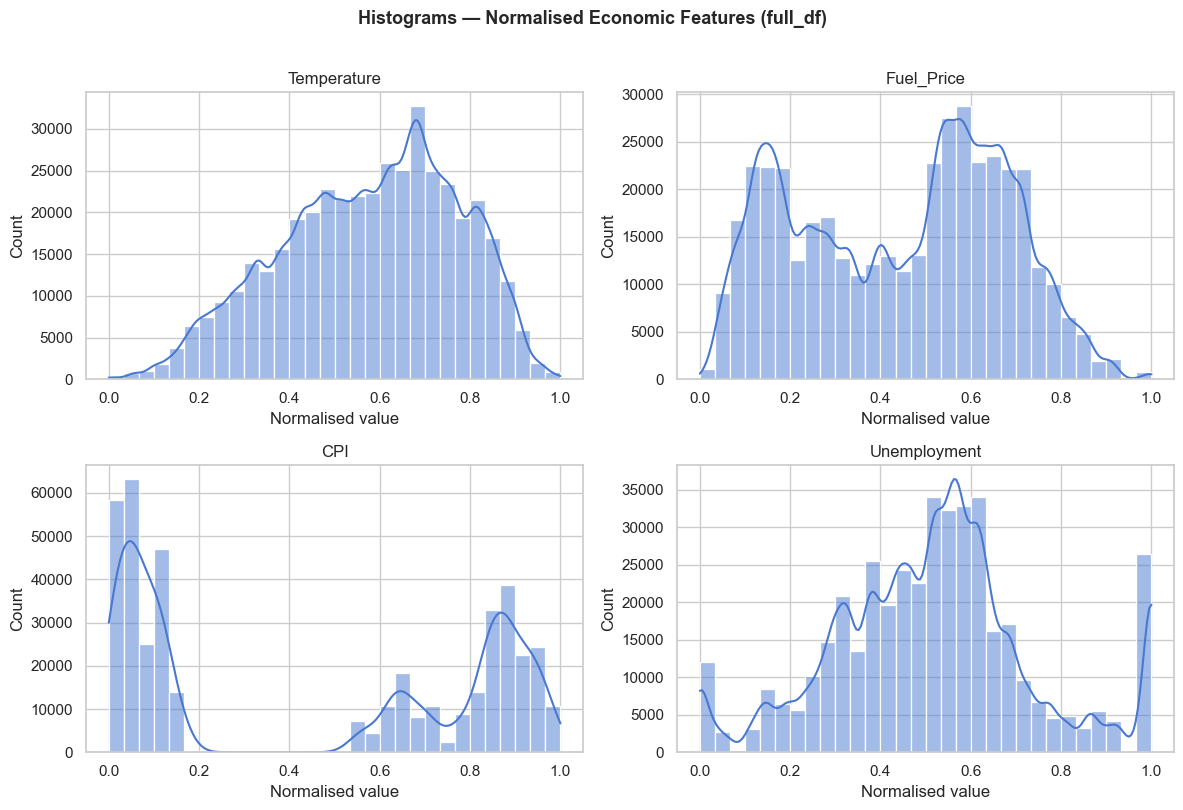

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Histograms — Normalised Economic Features (full_df)',
             fontsize=13, fontweight='bold', y=1.01)

for i, col in enumerate(econ_cols):
    ax = axes[i // 2, i % 2]
    sns.histplot(full_df[col].dropna(), bins=30, kde=True, ax=ax)
    ax.set_title(col)
    ax.set_xlabel('Normalised value')

plt.tight_layout()
plt.show()

---

## 📊 Section 11 — EDA: Weekly Sales vs Holiday

### 🎯 Objective
Understand how `IsHoliday` affects `Weekly_Sales`.

### 🧠 Why?
Holiday weeks are expected to produce higher sales due to increased consumer spending around major events (Thanksgiving, Christmas). Confirming this validates the feature.

### 📊 Insight
If the holiday boxplot median is visibly higher, holiday status is a strong predictor.

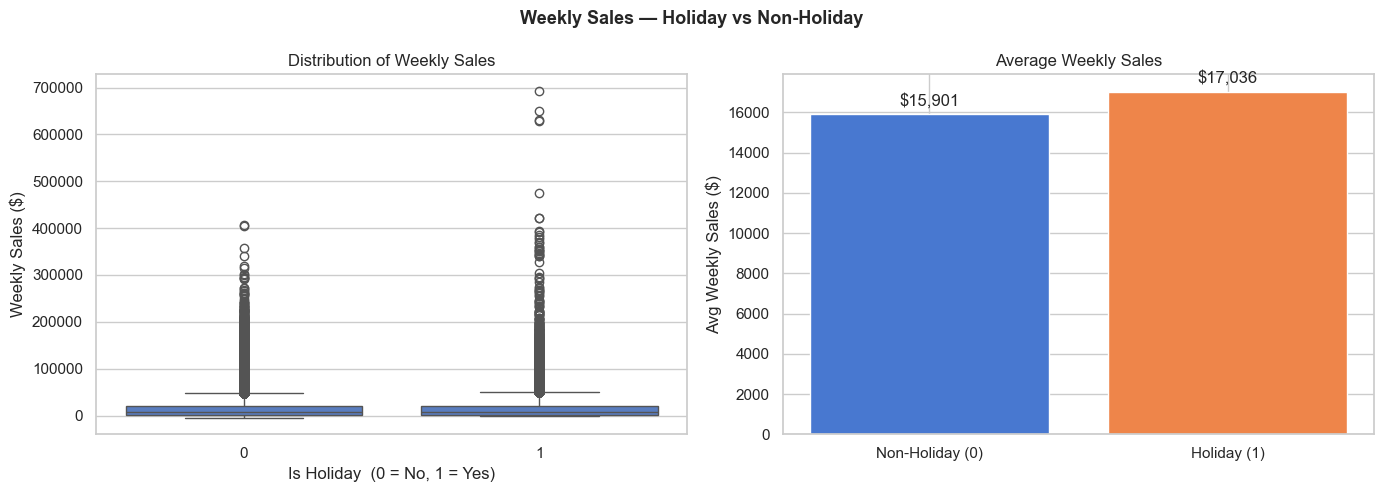


📊 Mean Weekly Sales by Holiday:
IsHoliday
Non-Holiday    $15,901.45
Holiday        $17,035.82


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Weekly Sales — Holiday vs Non-Holiday', fontsize=13, fontweight='bold')

# ── Boxplot ───────────────────────────────────────────────────────────────────
sns.boxplot(
    x='IsHoliday', y='Weekly_Sales',
    data=full_df, ax=axes[0]
)
axes[0].set_title('Distribution of Weekly Sales')
axes[0].set_xlabel('Is Holiday  (0 = No, 1 = Yes)')
axes[0].set_ylabel('Weekly Sales ($)')

# ── Mean bar chart ────────────────────────────────────────────────────────────
avg = full_df.groupby('IsHoliday')['Weekly_Sales'].mean()
bars = axes[1].bar(
    ['Non-Holiday (0)', 'Holiday (1)'],
    avg.values,
    color=sns.color_palette('muted')[:2]
)
axes[1].bar_label(bars, fmt='${:,.0f}', padding=4)
axes[1].set_title('Average Weekly Sales')
axes[1].set_ylabel('Avg Weekly Sales ($)')

plt.tight_layout()
plt.show()

print('\n📊 Mean Weekly Sales by Holiday:')
print(avg.rename({0: 'Non-Holiday', 1: 'Holiday'}).apply(lambda x: f'${x:,.2f}').to_string())

---

## 📊 Section 12 — EDA: MarkDown vs Weekly Sales (Before vs After Nov 2011)

### 🎯 Objective
Compare the relationship between `MarkDown` and `Weekly_Sales` across the key temporal boundary of **November 2011**, when MarkDown data became reliably populated.

### 📊 Insight
A positive slope in the *After Nov 2011* scatter — absent in the *Before* plot — confirms that MarkDown is a meaningful sales driver.

Records before Nov 2011 : 267,184
Records from  Nov 2011+ : 154,386


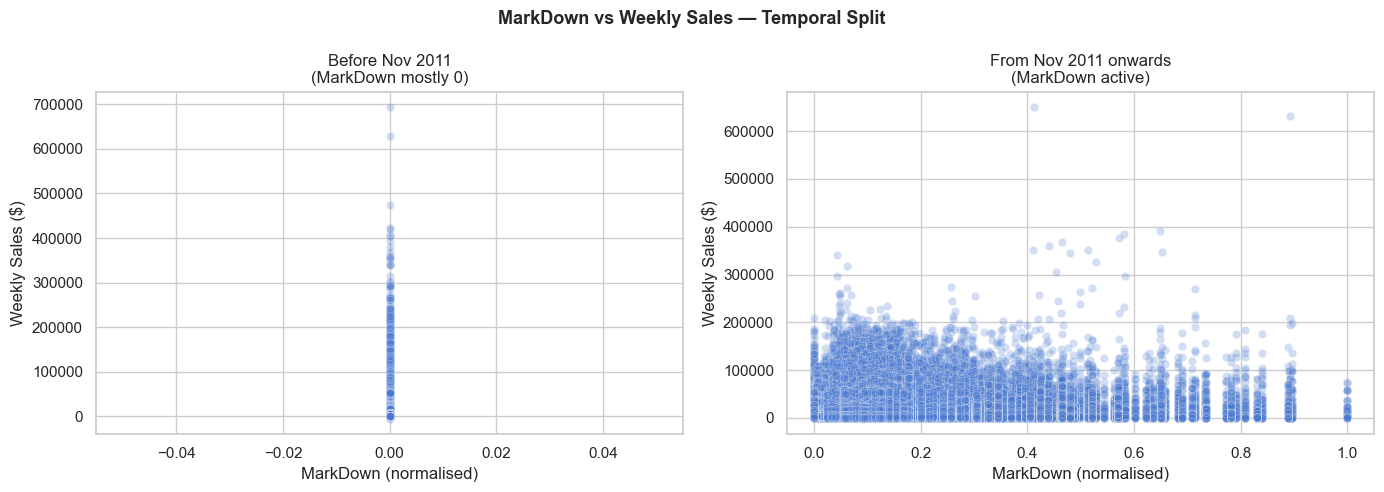

In [20]:
before_df = full_df[full_df['Date'] <  '2011-11-01']
after_df  = full_df[full_df['Date'] >= '2011-11-01']

print(f'Records before Nov 2011 : {len(before_df):,}')
print(f'Records from  Nov 2011+ : {len(after_df):,}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MarkDown vs Weekly Sales — Temporal Split',
             fontsize=13, fontweight='bold')

for ax, df, title in [
    (axes[0], before_df, 'Before Nov 2011\n(MarkDown mostly 0)'),
    (axes[1], after_df,  'From Nov 2011 onwards\n(MarkDown active)')
]:
    sns.scatterplot(
        x='MarkDown', y='Weekly_Sales',
        data=df.dropna(subset=['MarkDown', 'Weekly_Sales']),
        alpha=0.25, ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel('MarkDown (normalised)')
    ax.set_ylabel('Weekly Sales ($)')

plt.tight_layout()
plt.show()

---

## 📊 Section 13 — EDA: MarkDown vs Weekly Sales (Holiday Split)

### 🎯 Objective
Determine whether promotional activity (`MarkDown`) has a stronger effect on sales during **holiday** vs **non-holiday** weeks.

### 📊 Insight
Denser scatter at higher MarkDown values during holidays would indicate that promotions and holidays jointly amplify sales — a strong case for an interaction feature.

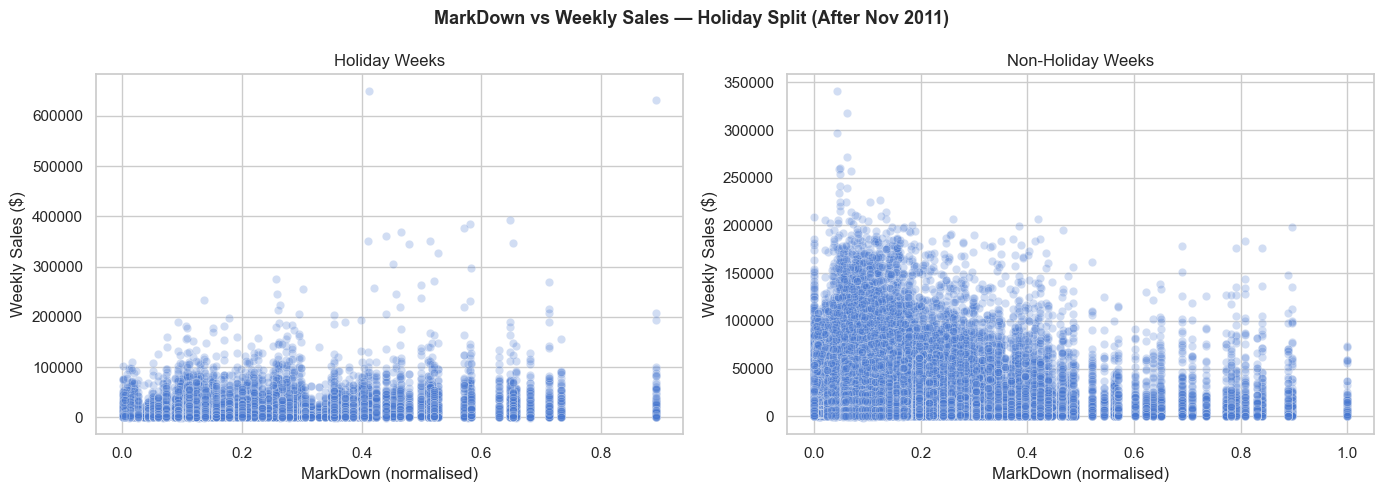

In [21]:
after_df_eda = full_df[full_df['Date'] >= '2011-11-01']

holiday_df     = after_df_eda[after_df_eda['IsHoliday'] == 1]
non_holiday_df = after_df_eda[after_df_eda['IsHoliday'] == 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MarkDown vs Weekly Sales — Holiday Split (After Nov 2011)',
             fontsize=13, fontweight='bold')

for ax, df, title in [
    (axes[0], holiday_df,     'Holiday Weeks'),
    (axes[1], non_holiday_df, 'Non-Holiday Weeks')
]:
    sns.scatterplot(
        x='MarkDown', y='Weekly_Sales',
        data=df.dropna(subset=['MarkDown', 'Weekly_Sales']),
        alpha=0.25, ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel('MarkDown (normalised)')
    ax.set_ylabel('Weekly Sales ($)')

plt.tight_layout()
plt.show()

---

## 📊 Section 14 — EDA: Economic Features vs Weekly Sales (Holiday Split)

### 🎯 Objective
Analyse how `Temperature`, `Fuel_Price`, `CPI`, and `Unemployment` relate to `Weekly_Sales`, separately for holiday and non-holiday weeks.

### 📊 Insight
Features with a visible positive or negative slope suggest linear predictability. Features with flat, noisy scatter may need polynomial or interaction terms.

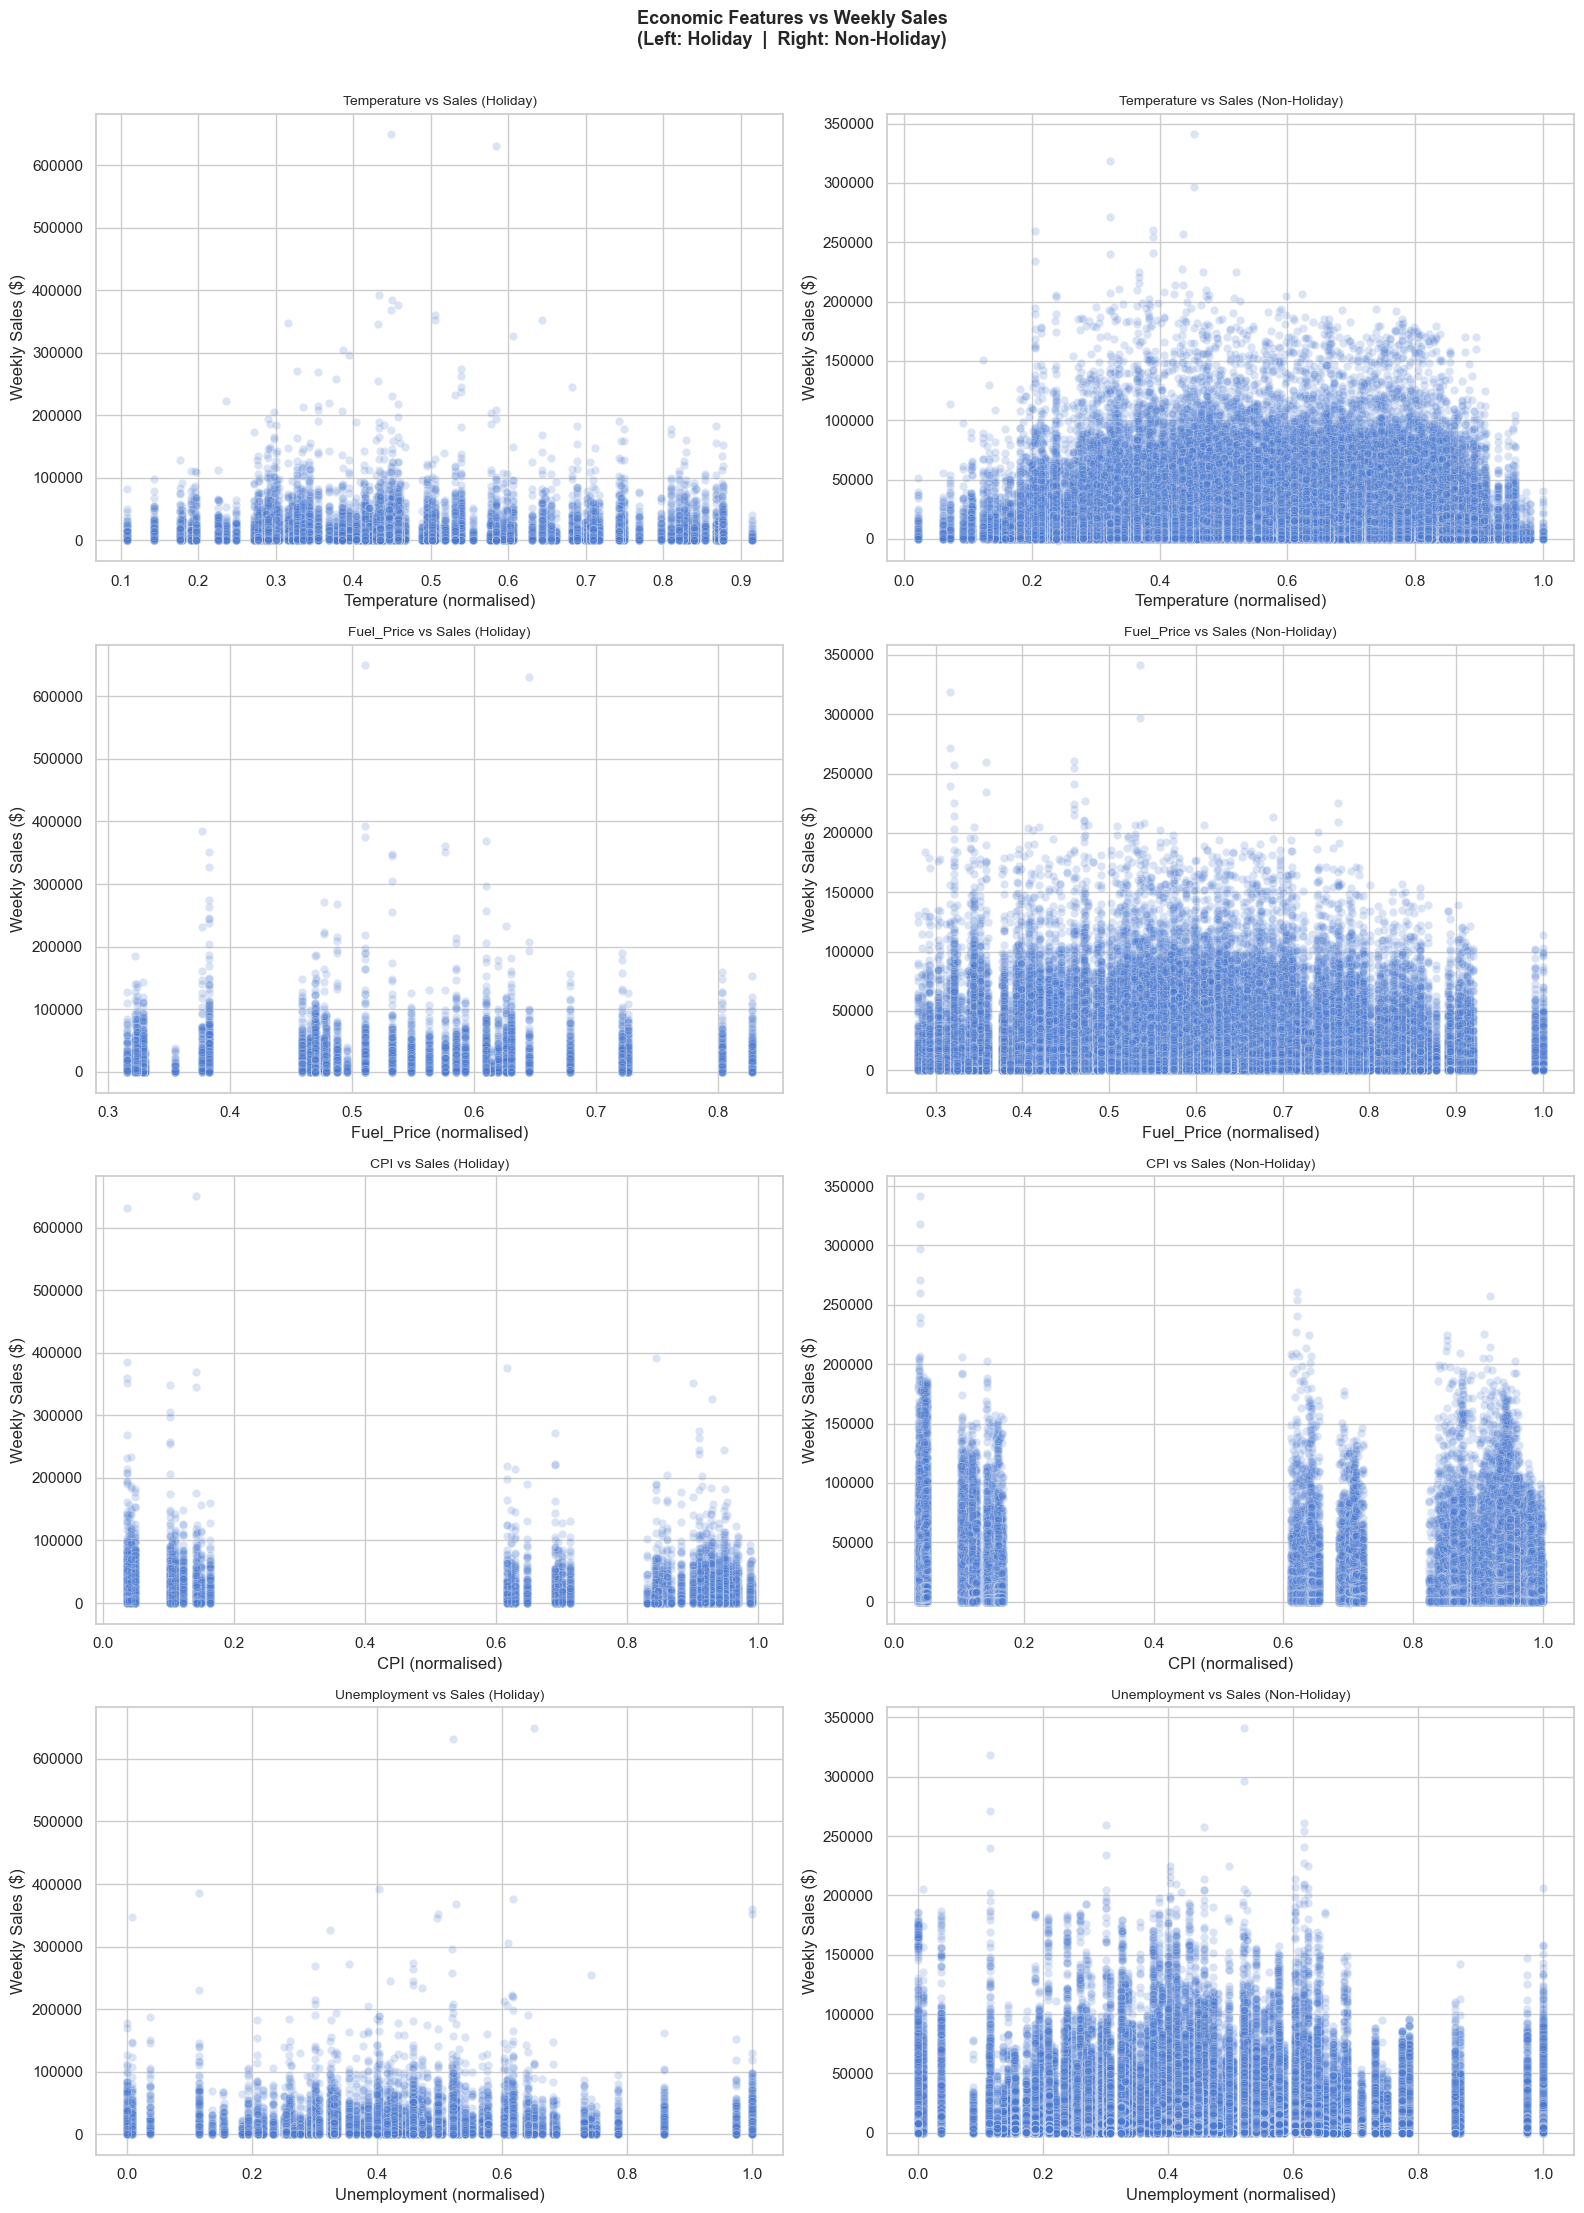

In [22]:
fig, axes = plt.subplots(4, 2, figsize=(16, 22))
fig.suptitle('Economic Features vs Weekly Sales\n(Left: Holiday  |  Right: Non-Holiday)',
             fontsize=13, fontweight='bold', y=1.005)

for i, feature in enumerate(econ_cols):
    for j, (df, label) in enumerate([
        (holiday_df,     f'{feature} vs Sales (Holiday)'),
        (non_holiday_df, f'{feature} vs Sales (Non-Holiday)')
    ]):
        ax = axes[i, j]
        plot_data = df.dropna(subset=[feature, 'Weekly_Sales'])
        sns.scatterplot(
            x=feature, y='Weekly_Sales',
            data=plot_data, alpha=0.2, ax=ax
        )
        ax.set_title(label, fontsize=10)
        ax.set_xlabel(f'{feature} (normalised)')
        ax.set_ylabel('Weekly Sales ($)')

plt.tight_layout()
plt.show()

---

## ✅ Section 15 — Pipeline Completion Checklist

### 🎯 Objective
Programmatically confirm every pipeline stage completed correctly.

In [23]:
checks = []

def check(label, condition, detail=''):
    status = '✅ PASS' if condition else '❌ FAIL'
    checks.append((label, condition))
    print(f'  {status}  {label}' + (f'  ({detail})' if detail else ''))

print('═' * 58)
print('         PIPELINE COMPLETION CHECKLIST')
print('═' * 58)

check('full_df created',           'full_df' in dir(),            f'shape={full_df.shape}')
check('Weekly_Sales present',      'Weekly_Sales' in full_df.columns)
check('MarkDown present',          'MarkDown' in full_df.columns)
check('Size present',              'Size' in full_df.columns)
check('MarkDown1–5 dropped',       all(f'MarkDown{i}' not in full_df.columns for i in range(1, 6)))
check('Store Type present',        'Type' in full_df.columns)
check('IsHoliday is int',          full_df['IsHoliday'].dtype in ['int32', 'int64'])
check('Date is datetime',          str(full_df['Date'].dtype).startswith('datetime'))

for col in ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'MarkDown']:
    lo = full_df[col].min()
    hi = full_df[col].max()
    check(f'{col} normalised [0,1]',
          round(lo, 4) >= 0 and round(hi, 4) <= 1,
          f'min={lo:.4f}, max={hi:.4f}')

check('Weekly_Sales NOT normalised',
      full_df['Weekly_Sales'].max() > 1,
      'target variable kept on original scale')

print('─' * 58)
n_pass = sum(c for _, c in checks)
n_fail = len(checks) - n_pass
print(f'  Result: {n_pass}/{len(checks)} checks passed   ({n_fail} failed)')
if n_fail == 0:
    print('\n  🎉 full_df is clean and ready for ML model training.')
else:
    print('\n  ⚠️  Fix failing checks before proceeding to model training.')

══════════════════════════════════════════════════════════
         PIPELINE COMPLETION CHECKLIST
══════════════════════════════════════════════════════════
  ✅ PASS  full_df created  (shape=(421570, 12))
  ✅ PASS  Weekly_Sales present
  ✅ PASS  MarkDown present
  ✅ PASS  Size present
  ✅ PASS  MarkDown1–5 dropped
  ✅ PASS  Store Type present
  ✅ PASS  IsHoliday is int
  ✅ PASS  Date is datetime
  ✅ PASS  Temperature normalised [0,1]  (min=0.0000, max=1.0000)
  ✅ PASS  Fuel_Price normalised [0,1]  (min=0.0000, max=1.0000)
  ✅ PASS  CPI normalised [0,1]  (min=0.0000, max=1.0000)
  ✅ PASS  Unemployment normalised [0,1]  (min=0.0000, max=1.0000)
  ✅ PASS  MarkDown normalised [0,1]  (min=0.0000, max=1.0000)
  ✅ PASS  Weekly_Sales NOT normalised  (target variable kept on original scale)
──────────────────────────────────────────────────────────
  Result: 14/14 checks passed   (0 failed)

  🎉 full_df is clean and ready for ML model training.


---

# 🌲 Section 16 — Machine Learning: Random Forest Regression

---

## 🎯 Objective

Train a **Random Forest Regressor** to predict `Weekly_Sales` using the fully preprocessed `full_df` dataset.

### 🧠 Why Random Forest?

- ✅ **Handles mixed feature types** — numeric, encoded categorical (Store Type), and binary flags (IsHoliday) all work natively
- ✅ **Robust to outliers** — tree splits are rank-based, not magnitude-based
- ✅ **No assumptions about normality** — the target `Weekly_Sales` is right-skewed; Random Forest is unaffected
- ✅ **Built-in feature importance** — measures contribution of each variable without additional tooling

### 📋 ML Pipeline Overview

```
full_df
 ├── Feature selection       →  X_raw (drop target, date)
 ├── One-hot encode          →  Store, Dept, Type → binary columns
 ├── Chronological split     →  80% earliest dates → train | 20% latest → test  ← FIX #4
 ├── Scaler fit on train     →  fit MinMaxScaler on X_train only                 ← FIX #3
 ├── Scaler transform test   →  transform X_test (no fit)
 ├── Model training          →  RandomForestRegressor(n_estimators=100)
 └── Evaluation              →  MAE · RMSE · R²
```

## 🔍 Section 16.1 — Feature Selection

### 🎯 Objective
Select the correct set of input features (`X`) and target variable (`y`), while removing columns that would cause **data leakage** or are **non-numeric identifiers**.

| Column | Decision | Reason |
|--------|----------|---------|
| `Weekly_Sales` | ❌ **Target — excluded from X** | This is what we predict |
| `Date` | ❌ **Dropped** | Raw datetime is not numeric |
| `Type` | ✅ **One-hot encoded** | Store type (A/B/C) is nominal |
| `Store` | ✅ **One-hot encoded** | Store ID is nominal — not ordered |
| `Dept` | ✅ **One-hot encoded** | Department ID is nominal — not ordered |

In [24]:
# ── Target variable ───────────────────────────────────────────────────────────
y = full_df['Weekly_Sales'].copy()

# ── Feature matrix: drop target and non-numeric date ─────────────────────────
drop_cols = ['Weekly_Sales', 'Date']
X_raw = full_df.drop(columns=[c for c in drop_cols if c in full_df.columns])

# ── One-hot encode nominal categorical columns ────────────────────────────────
cat_cols = [c for c in ['Type', 'Store', 'Dept'] if c in X_raw.columns]
if cat_cols:
    X_raw = pd.get_dummies(X_raw, columns=cat_cols, drop_first=True)
    print(f'✅ One-hot encoded categorical columns: {cat_cols}')

# ── Fill any residual NaN with column median ──────────────────────────────────
null_before = X_raw.isnull().sum().sum()
X_raw = X_raw.fillna(X_raw.median(numeric_only=True))
null_after  = X_raw.isnull().sum().sum()

if null_before > 0:
    print(f'⚠️  Filled {null_before} NaN values with column medians → {null_after} remaining')
else:
    print('✅ No NaN values — feature matrix is clean.')

X = X_raw.copy()

print(f'\n── Feature Matrix ──────────────────────────────────')
print(f'  Shape : {X.shape}  ({X.shape[0]:,} rows × {X.shape[1]} features)')
print(f'  Target: y  shape = {y.shape}')
base_cols = ['IsHoliday', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'MarkDown', 'Size']
print(f'\n  Continuous / binary features:')
for col in base_cols:
    if col in X.columns:
        print(f'    • {col}  (dtype: {X[col].dtype})')
enc_cols = [c for c in X.columns if c not in base_cols]
print(f'\n  One-hot encoded columns  : {len(enc_cols)}  (Store_*, Dept_*, Type_*)')
print(f'  Total features           : {X.shape[1]}')

✅ One-hot encoded categorical columns: ['Type', 'Store', 'Dept']
✅ No NaN values — feature matrix is clean.

── Feature Matrix ──────────────────────────────────
  Shape : (421570, 133)  (421,570 rows × 133 features)
  Target: y  shape = (421570,)

  Continuous / binary features:
    • IsHoliday  (dtype: int64)
    • Temperature  (dtype: float64)
    • Fuel_Price  (dtype: float64)
    • CPI  (dtype: float64)
    • Unemployment  (dtype: float64)
    • MarkDown  (dtype: float64)
    • Size  (dtype: int64)

  One-hot encoded columns  : 126  (Store_*, Dept_*, Type_*)
  Total features           : 133


## ✂️ Section 16.2 — Chronological Train / Test Split

### 🐛 Fix #4 Applied Here

**The original v3 notebook used `train_test_split` with `random_state=42`** — a completely random shuffle. For time-series data this is wrong: it lets the model see **future weeks during training** and predict **past weeks during testing**, which is the opposite of real forecasting.

**The fix:** Sort by `Date`, take the earliest 80% of rows for training and the latest 20% for testing. This way the model only ever sees data from before the dates it's predicting.

### 📊 Interpretation
The training cutoff date printed below is the boundary — everything before it trains the model, everything after it tests generalisation.

In [25]:
# ── FIX #4: Chronological split ───────────────────────────────────────────────
# Sort by the Date column from full_df (aligned with X and y by index)
sorted_index = full_df.sort_values('Date').index

X_sorted = X.loc[sorted_index].reset_index(drop=True)
y_sorted = y.loc[sorted_index].reset_index(drop=True)
dates_sorted = full_df.loc[sorted_index, 'Date'].reset_index(drop=True)

split_idx = int(len(X_sorted) * 0.80)

X_train = X_sorted.iloc[:split_idx]
X_test  = X_sorted.iloc[split_idx:]
y_train = y_sorted.iloc[:split_idx]
y_test  = y_sorted.iloc[split_idx:]

train_date_max = dates_sorted.iloc[split_idx - 1]
test_date_min  = dates_sorted.iloc[split_idx]

print('✅ Chronological Train / Test split complete.')
print(f'  Training set : {X_train.shape[0]:>7,} rows  ({X_train.shape[0]/len(X_sorted)*100:.1f}%)')
print(f'  Test set     : {X_test.shape[0]:>7,} rows  ({X_test.shape[0]/len(X_sorted)*100:.1f}%)')
print(f'  Features     : {X_train.shape[1]}')
print(f'\n  Training date range  : {dates_sorted.iloc[0].date()}  →  {train_date_max.date()}')
print(f'  Test date range      : {test_date_min.date()}  →  {dates_sorted.iloc[-1].date()}')
print(f'\n  ✅ No future data leaks into training — model predicts genuinely unseen weeks.')

✅ Chronological Train / Test split complete.
  Training set : 337,256 rows  (80.0%)
  Test set     :  84,314 rows  (20.0%)
  Features     : 133

  Training date range  : 2010-02-05  →  2012-04-13
  Test date range      : 2012-04-13  →  2012-10-26

  ✅ No future data leaks into training — model predicts genuinely unseen weeks.


## ⚖️ Section 16.3 — Scaler Fit on Train Only (No Leakage)

### 🐛 Fix #3 Applied Here

The scaler is **fit only on `X_train`** and then applied to both train and test. This ensures test-set values never influence the scaling parameters — a form of data leakage that would make test metrics look artificially better.

The EDA copy in Section 8 used the full dataset for display purposes only. This is the real ML-safe scaler.

In [26]:
ml_cols_to_scale = [c for c in ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'MarkDown']
                    if c in X_train.columns]

# FIX #3: fit ONLY on training data
ml_scaler = MinMaxScaler()
X_train = X_train.copy()
X_test  = X_test.copy()

X_train[ml_cols_to_scale] = ml_scaler.fit_transform(X_train[ml_cols_to_scale])   # fit + transform
X_test[ml_cols_to_scale]  = ml_scaler.transform(X_test[ml_cols_to_scale])         # transform only

print('✅ ML-safe scaling complete.')
print('   Scaler fitted on TRAINING rows only.')
print('   Test rows transformed using training min/max (no leakage).')
print(f'\n   Columns scaled: {ml_cols_to_scale}')

✅ ML-safe scaling complete.
   Scaler fitted on TRAINING rows only.
   Test rows transformed using training min/max (no leakage).

   Columns scaled: ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'MarkDown']


## 🌲 Section 16.4 — Model Training: Random Forest Regressor

### 🧠 Hyperparameter Rationale

| Hyperparameter | Value | Rationale |
|----------------|-------|-----------|
| `n_estimators` | `100` | Industry-standard default; balances accuracy and training time |
| `max_depth` | `None` | Trees grow fully — Random Forest's bagging prevents overfitting without depth restriction |
| `n_jobs` | `-1` | Uses all CPU cores for parallel tree building |
| `random_state` | `42` | Ensures reproducibility across runs |

In [27]:
print('🌲 Training Random Forest Regressor ...')
print('   (n_estimators=100 · n_jobs=-1 · random_state=42)\n')

rf_model = RandomForestRegressor(
    n_estimators = 100,
    random_state = 42,
    n_jobs       = -1
)

t0 = time.time()
rf_model.fit(X_train, y_train)
elapsed = time.time() - t0

print(f'✅ Model training complete in {elapsed:.1f} seconds.')
print(f'   Trees built       : {rf_model.n_estimators}')
print(f'   Input features    : {rf_model.n_features_in_}')

🌲 Training Random Forest Regressor ...
   (n_estimators=100 · n_jobs=-1 · random_state=42)

✅ Model training complete in 242.2 seconds.
   Trees built       : 100
   Input features    : 133


## 📊 Section 16.5 — Model Evaluation

### 🧠 Metrics Explained

| Metric | What it measures | Units |
|--------|-----------------|-------|
| **MAE** | Average dollar error per prediction — easy to interpret | $ |
| **RMSE** | Penalises large errors more heavily than MAE | $ |
| **R²** | Proportion of variance explained; 1.0 = perfect | dimensionless |

### 📊 Interpretation Guide
- **R² > 0.90** → Excellent fit for a retail demand model
- **MAE < 5,000** → Typical weekly store-level prediction is within $5K of actual
- **RMSE significantly > MAE** → Model makes occasional large errors on high-volume holiday weeks

In [28]:
# ── Predictions ───────────────────────────────────────────────────────────────
y_pred_test  = rf_model.predict(X_test)
y_pred_train = rf_model.predict(X_train)

# ── Metrics — Test set ────────────────────────────────────────────────────────
mae  = mean_absolute_error(y_test,  y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2   = r2_score(y_test,  y_pred_test)

# ── Metrics — Train set (overfitting check) ───────────────────────────────────
mae_tr  = mean_absolute_error(y_train,  y_pred_train)
rmse_tr = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_tr   = r2_score(y_train,  y_pred_train)

# ── Print results ─────────────────────────────────────────────────────────────
print('=' * 58)
print('        RANDOM FOREST REGRESSOR — RESULTS')
print('=' * 58)
print(f'\n  {"Metric":<30} {"Train":>10}  {"Test":>10}')
print(f'  {"-"*30} {"-"*10}  {"-"*10}')
print(f'  {"MAE  (Mean Abs. Error)":<30} {mae_tr:>10,.2f}  {mae:>10,.2f}')
print(f'  {"RMSE (Root Mean Sq. Err.)":<30} {rmse_tr:>10,.2f}  {rmse:>10,.2f}')
print(f'  {"R²   (R-Squared)":<30} {r2_tr:>10.4f}  {r2:>10.4f}')
print('─' * 58)
print(f'\n  📌 Test MAE  : ${mae:,.2f}  — average prediction error per row')
print(f'  📌 Test RMSE : ${rmse:,.2f}  — penalised for large errors')
print(f'  📌 Test R²   :  {r2:.4f}   — proportion of variance explained')

r2_pct = r2 * 100
print(f'\n  📌 Model Accuracy (R²): {r2_pct:.2f}%')

gap = r2_tr - r2
print(f'\n  🔍 Train R² - Test R² = {gap:.4f}', end='')
if gap < 0.05:
    print(' → ✅ Low overfitting gap — model generalises well.')
elif gap < 0.15:
    print(' → ⚠️  Moderate overfitting — consider tuning max_depth or min_samples_leaf.')
else:
    print(' → ❌ High overfitting — model has memorised training data.')

        RANDOM FOREST REGRESSOR — RESULTS

  Metric                              Train        Test
  ------------------------------ ----------  ----------
  MAE  (Mean Abs. Error)             729.49    2,653.58
  RMSE (Root Mean Sq. Err.)        2,125.09    5,297.52
  R²   (R-Squared)                   0.9914      0.9417
──────────────────────────────────────────────────────────

  📌 Test MAE  : $2,653.58  — average prediction error per row
  📌 Test RMSE : $5,297.52  — penalised for large errors
  📌 Test R²   :  0.9417   — proportion of variance explained

  📌 Model Accuracy (R²): 94.17%

  🔍 Train R² - Test R² = 0.0496 → ✅ Low overfitting gap — model generalises well.


## 📈 Section 16.6 — Feature Importance Analysis

### 🧠 What to expect
- `Dept_*` and `Store_*` one-hot columns will collectively rank highest — store and department identity is the strongest signal in weekly retail sales
- `Size` should rank highly — larger stores naturally generate more revenue
- `IsHoliday` and `MarkDown` contribute meaningfully, confirming EDA insights
- Economic indicators (`CPI`, `Unemployment`, `Fuel_Price`, `Temperature`) rank lower — macro effects are real but secondary to store-level patterns

Top 15 Features by Importance:
    Feature  Importance
       Size    0.189233
    Dept_92    0.101596
    Dept_95    0.086381
    Dept_38    0.065164
    Dept_72    0.042853
    Dept_90    0.039379
    Dept_40    0.033113
     Dept_2    0.031602
Temperature    0.031284
        CPI    0.030414
    Dept_91    0.024736
 Fuel_Price    0.022256
    Dept_94    0.019368
   Store_10    0.018211
    Dept_13    0.015084


C:\Users\oem\AppData\Local\Temp\ipykernel_4532\4241382004.py:33: UserWarning: Glyph 127794 (\N{EVERGREEN TREE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\oem\AppData\Local\Temp\ipykernel_4532\4241382004.py:34: UserWarning: Glyph 127794 (\N{EVERGREEN TREE}) missing from font(s) Arial.
  plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
c:\Users\oem\miniconda3\envs\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127794 (\N{EVERGREEN TREE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


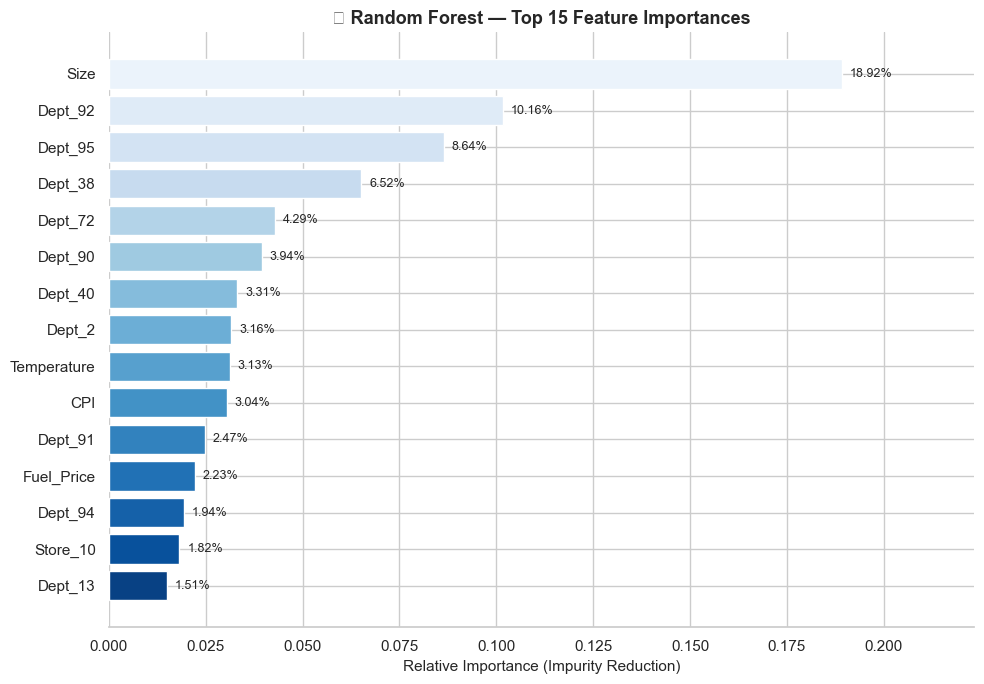

✅ Feature importance chart saved to feature_importance.png


In [29]:
feat_imp = pd.DataFrame({
    'Feature'   : X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print('Top 15 Features by Importance:')
print(feat_imp.head(15).to_string(index=False))

n_show = min(len(feat_imp), 15)
top_n  = feat_imp.head(n_show)

palette = sns.color_palette('Blues_r', n_show)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(
    top_n['Feature'][::-1],
    top_n['Importance'][::-1],
    color=palette
)

for bar, val in zip(bars, top_n['Importance'][::-1]):
    ax.text(
        bar.get_width() + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f'{val*100:.2f}%',
        va='center', ha='left', fontsize=9
    )

ax.set_xlabel('Relative Importance (Impurity Reduction)', fontsize=11)
ax.set_title(f'🌲 Random Forest — Top {n_show} Feature Importances', fontsize=13, fontweight='bold')
ax.set_xlim(0, top_n['Importance'].max() * 1.18)
sns.despine(left=True)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Feature importance chart saved to feature_importance.png')

## 🔮 Section 16.7 — Prediction Visualisation: Actual vs Predicted

### 📊 Interpretation
- Points **above** the diagonal → model under-predicts (actual > predicted)
- Points **below** the diagonal → model over-predicts
- A **right-skewed residual distribution** signals that very high sales weeks (holiday spikes) are harder to predict precisely

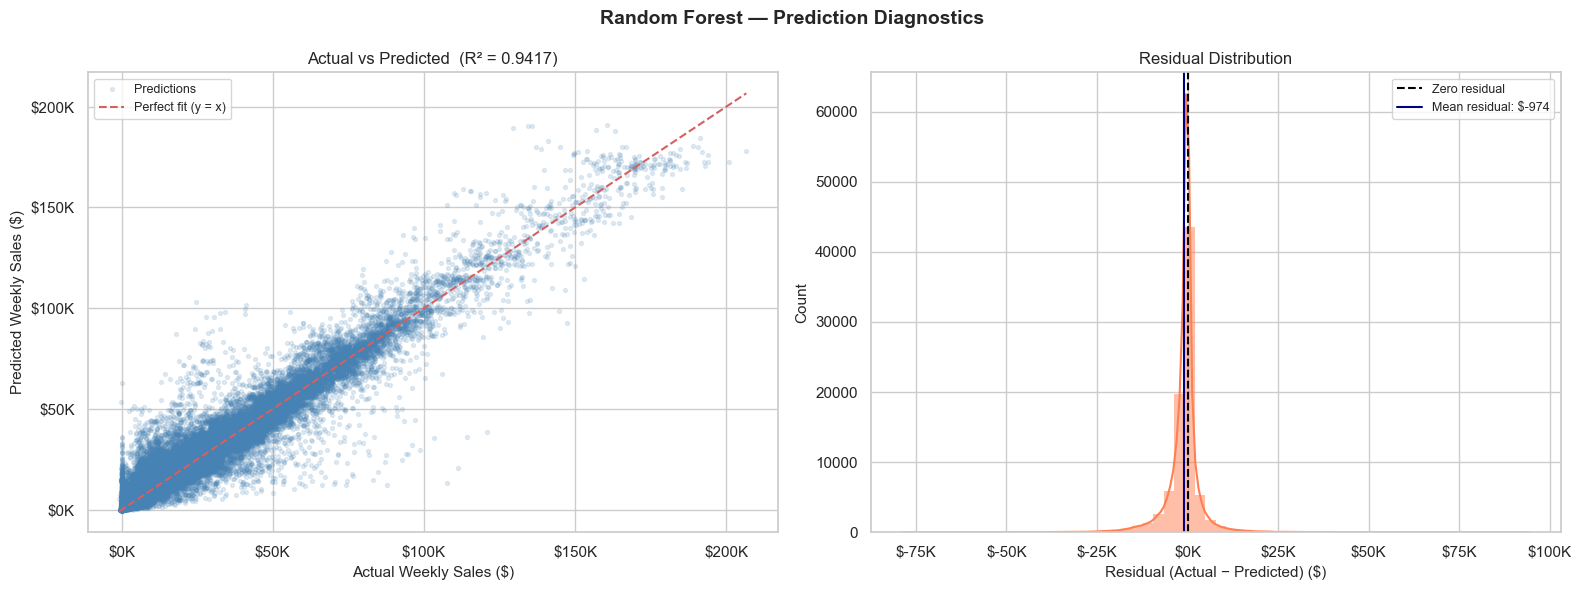

✅ Prediction diagnostics chart saved to prediction_diagnostics.png

  Residual mean  : $   -973.90  (bias)
  Residual std   : $  5,207.23  (spread of errors)
  Residual median: $   -273.49


In [30]:
residuals = y_test.values - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Random Forest — Prediction Diagnostics', fontsize=14, fontweight='bold')

# ── Left: Actual vs Predicted ─────────────────────────────────────────────────
ax = axes[0]
ax.scatter(y_test, y_pred_test, alpha=0.15, s=8, color='steelblue', label='Predictions')
lims = [min(y_test.min(), y_pred_test.min()),
        max(y_test.max(), y_pred_test.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit (y = x)')
ax.set_xlabel('Actual Weekly Sales ($)', fontsize=11)
ax.set_ylabel('Predicted Weekly Sales ($)', fontsize=11)
ax.set_title(f'Actual vs Predicted  (R² = {r2:.4f})', fontsize=12)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

# ── Right: Residual distribution ─────────────────────────────────────────────
ax2 = axes[1]
sns.histplot(residuals, bins=60, kde=True, ax=ax2, color='coral', edgecolor='none')
ax2.axvline(0, color='black', linestyle='--', linewidth=1.5, label='Zero residual')
ax2.axvline(residuals.mean(), color='navy', linestyle='-', linewidth=1.5,
            label=f'Mean residual: ${residuals.mean():,.0f}')
ax2.set_xlabel('Residual (Actual − Predicted) ($)', fontsize=11)
ax2.set_ylabel('Count', fontsize=11)
ax2.set_title('Residual Distribution', fontsize=12)
ax2.legend(fontsize=9)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

plt.tight_layout()
plt.savefig('prediction_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ Prediction diagnostics chart saved to prediction_diagnostics.png')
print(f'\n  Residual mean  : ${residuals.mean():>10,.2f}  (bias)')
print(f'  Residual std   : ${residuals.std():>10,.2f}  (spread of errors)')
print(f'  Residual median: ${np.median(residuals):>10,.2f}')

## 🧪 Section 16.8 — Sample Predictions

### 🎯 Objective
Inspect individual predictions side-by-side with their actual values to sanity-check the model at row level.

In [31]:
comparison_df = pd.DataFrame({
    'Actual_Sales'   : y_test.values,
    'Predicted_Sales': y_pred_test,
    'Abs_Error'      : np.abs(y_test.values - y_pred_test),
    'Error_Pct'      : np.abs((y_test.values - y_pred_test) / (y_test.values + 1e-9)) * 100
})

pd.set_option('display.float_format', '${:,.2f}'.format)
print('── Sample Predictions (15 rows from test set) ───────────────')
print(comparison_df.head(15).to_string())
pd.reset_option('display.float_format')

print(f'\n── Summary Statistics ───────────────────────────────────────')
print(f'  Rows with Error < $1,000  : {(comparison_df["Abs_Error"] < 1000).sum():,}')
print(f'  Rows with Error < $5,000  : {(comparison_df["Abs_Error"] < 5000).sum():,}')
print(f'  Rows with Error < $10,000 : {(comparison_df["Abs_Error"] < 10000).sum():,}')
print(f'  Total test rows           : {len(comparison_df):,}')

── Sample Predictions (15 rows from test set) ───────────────
    Actual_Sales  Predicted_Sales  Abs_Error  Error_Pct
0     $25,890.80       $30,619.79  $4,728.99     $18.27
1     $91,691.90       $81,144.06 $10,547.84     $11.50
2     $28,446.31       $30,635.68  $2,189.37      $7.70
3      $1,943.18        $2,676.24    $733.06     $37.72
4      $7,563.94       $11,538.24  $3,974.30     $52.54
5     $10,434.61       $11,042.58    $607.97      $5.83
6     $14,368.12       $14,531.28    $163.16      $1.14
7          $7.97           $14.77      $6.80     $85.28
8      $2,749.30        $5,939.51  $3,190.21    $116.04
9      $2,019.50        $2,812.38    $792.88     $39.26
10    $27,909.70       $31,451.48  $3,541.78     $12.69
11     $3,431.50        $4,723.90  $1,292.40     $37.66
12     $1,555.89        $1,412.80    $143.09      $9.20
13       $799.00          $920.56    $121.56     $15.21
14       $147.00          $285.96    $138.96     $94.53

── Summary Statistics ───────────────────

## ✅ Section 16.9 — Final ML Pipeline Summary

In [32]:
print('╔' + '═' * 60 + '╗')
print('║       RANDOM FOREST REGRESSOR — FINAL SUMMARY (v4)        ║')
print('╠' + '═' * 60 + '╣')
print(f'║  Dataset             : full_df  {str(full_df.shape):<26} ║')
print(f'║  Features used       : {X_train.shape[1]:<35} ║')
print(f'║  Split method        : Chronological (no future leakage)  ║')
print(f'║  Training rows       : {X_train.shape[0]:>10,}  (80% earliest dates)  ║')
print(f'║  Test rows           : {X_test.shape[0]:>10,}  (20% latest dates)    ║')
print('╠' + '═' * 60 + '╣')
print(f'║  TEST MAE            : ${mae:>15,.2f}                    ║')
print(f'║  TEST RMSE           : ${rmse:>15,.2f}                    ║')
print(f'║  TEST R²             :  {r2:>15.4f}                    ║')
print(f'║  Model Accuracy (R²) :  {r2*100:>14.2f}%                    ║')
print('╠' + '═' * 60 + '╣')
print(f'║  Top Feature         : {feat_imp.iloc[0]["Feature"]:<37} ║')
print('╠' + '═' * 60 + '╣')
print('║  Fixes vs v3:                                              ║')
print('║  ✅ Size column no longer dropped before merge             ║')
print('║  ✅ Outlier capping moved BEFORE normalization             ║')
print('║  ✅ Scaler fitted on training rows only (no leakage)       ║')
print('║  ✅ Chronological split (no future data in training)       ║')
print('║  ✅ Duplicate save cells removed                           ║')
print('╚' + '═' * 60 + '╝')
print('\n🎉 Notebook complete — all bugs fixed, model trained and evaluated.')

╔════════════════════════════════════════════════════════════╗
║       RANDOM FOREST REGRESSOR — FINAL SUMMARY (v4)        ║
╠════════════════════════════════════════════════════════════╣
║  Dataset             : full_df  (421570, 12)               ║
║  Features used       : 133                                 ║
║  Split method        : Chronological (no future leakage)  ║
║  Training rows       :    337,256  (80% earliest dates)  ║
║  Test rows           :     84,314  (20% latest dates)    ║
╠════════════════════════════════════════════════════════════╣
║  TEST MAE            : $       2,653.58                    ║
║  TEST RMSE           : $       5,297.52                    ║
║  TEST R²             :           0.9417                    ║
║  Model Accuracy (R²) :           94.17%                    ║
╠════════════════════════════════════════════════════════════╣
║  Top Feature         : Size                                  ║
╠══════════════════════════════════════════════════════════

## 💾 Section 17 — Save Model

Saves the trained model and the exact feature column list to disk so they can be loaded by a Streamlit app or any other inference script.

In [33]:
# ── Save model and feature names ──────────────────────────────────────────────
# Edit save_dir to point to your project folder if needed.
save_dir = os.getcwd()   # defaults to the notebook's current directory

model_path    = os.path.join(save_dir, 'model.pkl')
features_path = os.path.join(save_dir, 'feature_names.json')

joblib.dump(rf_model, model_path)
with open(features_path, 'w') as f:
    json.dump(list(X_train.columns), f)

print(f'✅ model.pkl        saved → {model_path}')
print(f'✅ feature_names.json saved → {features_path}')
print(f'\nFiles in save directory:')
for fn in os.listdir(save_dir):
    if fn.endswith(('.pkl', '.json', '.png')):
        print(f'  {fn}')

✅ model.pkl        saved → e:\Junior\Semester 2\Machine Learning\Project\Codes\model.pkl
✅ feature_names.json saved → e:\Junior\Semester 2\Machine Learning\Project\Codes\feature_names.json

Files in save directory:
  feature_importance.png
  feature_names.json
  model.pkl
  prediction_diagnostics.png
